In [1]:
import platform
print(platform.python_version())

3.14.4


In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from string import ascii_letters
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

In [3]:
dataset = read_csv("classification_example_creditcard.csv")

## Data Exploration

In [4]:
dataset.shape

(284807, 31)

In [5]:
dataset.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
dataset.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
class_names = {0:'Not Fraud', 1:'Fraud'}
print(dataset.Class.value_counts().rename(index=class_names))

Class
Not Fraud    284315
Fraud           492
Name: count, dtype: int64


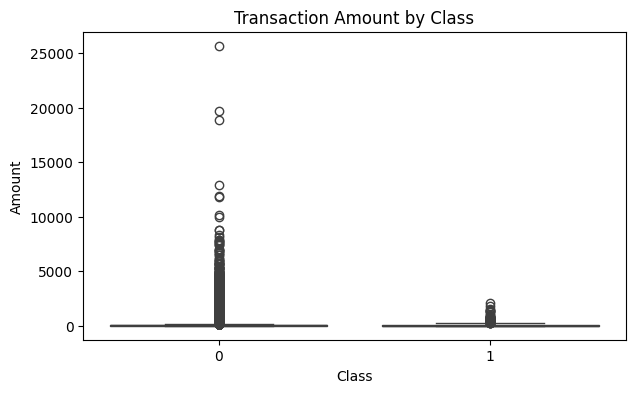

In [8]:
# 2) Amount by class (boxplot)

pyplot.figure(figsize=(7,4))
sns.boxplot(x="Class", y="Amount", data=dataset)
pyplot.title("Transaction Amount by Class")
pyplot.show()

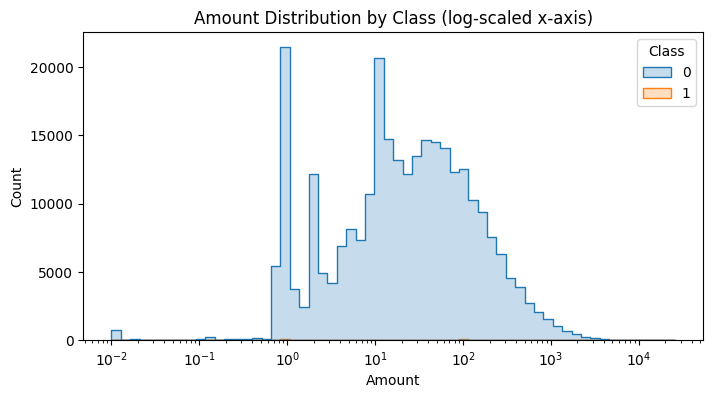

In [9]:
# 3) Amount distribution by class (log scale helps long tail)
pyplot.figure(figsize=(8,4))
sns.histplot(data=dataset, x="Amount", hue="Class", bins=60, element="step", stat="count", log_scale=True)
pyplot.title("Amount Distribution by Class (log-scaled x-axis)")
pyplot.show()

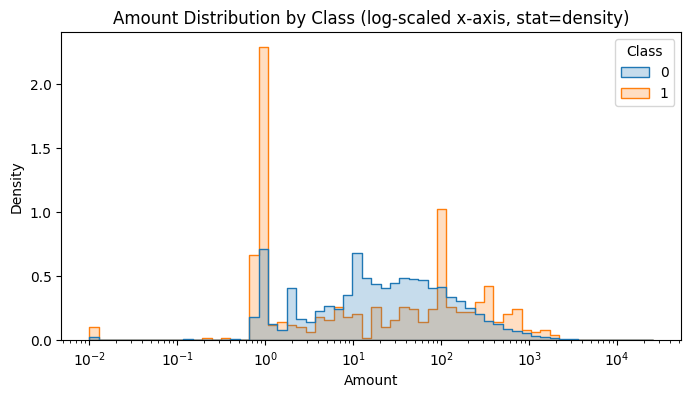

In [10]:
# 3) Amount distribution by class (log scale helps long tail)
pyplot.figure(figsize=(8,4))
sns.histplot(data=dataset, x="Amount", hue="Class", bins=60, element="step", stat="density", log_scale=True, common_norm=False)
pyplot.title("Amount Distribution by Class (log-scaled x-axis, stat=density)")
pyplot.show()

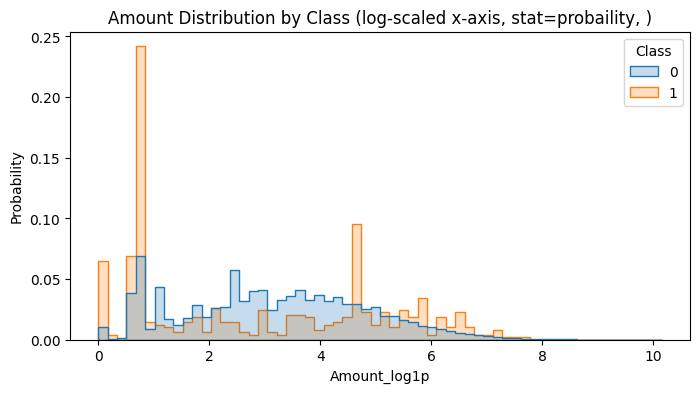

In [12]:
tmp = dataset.copy()
tmp["Amount_log1p"] = np.log1p(tmp["Amount"])  # handles zeros

plt.figure(figsize=(8,4))
pyplot.title("Amount Distribution by Class (log-scaled x-axis, stat=probaility, )")
sns.histplot(
    data=tmp,
    x="Amount_log1p",
    hue="Class",
    bins=60,
    stat="probability",
    common_norm=False,
    element="step"
)
plt.show()

Classes are unbalanced.

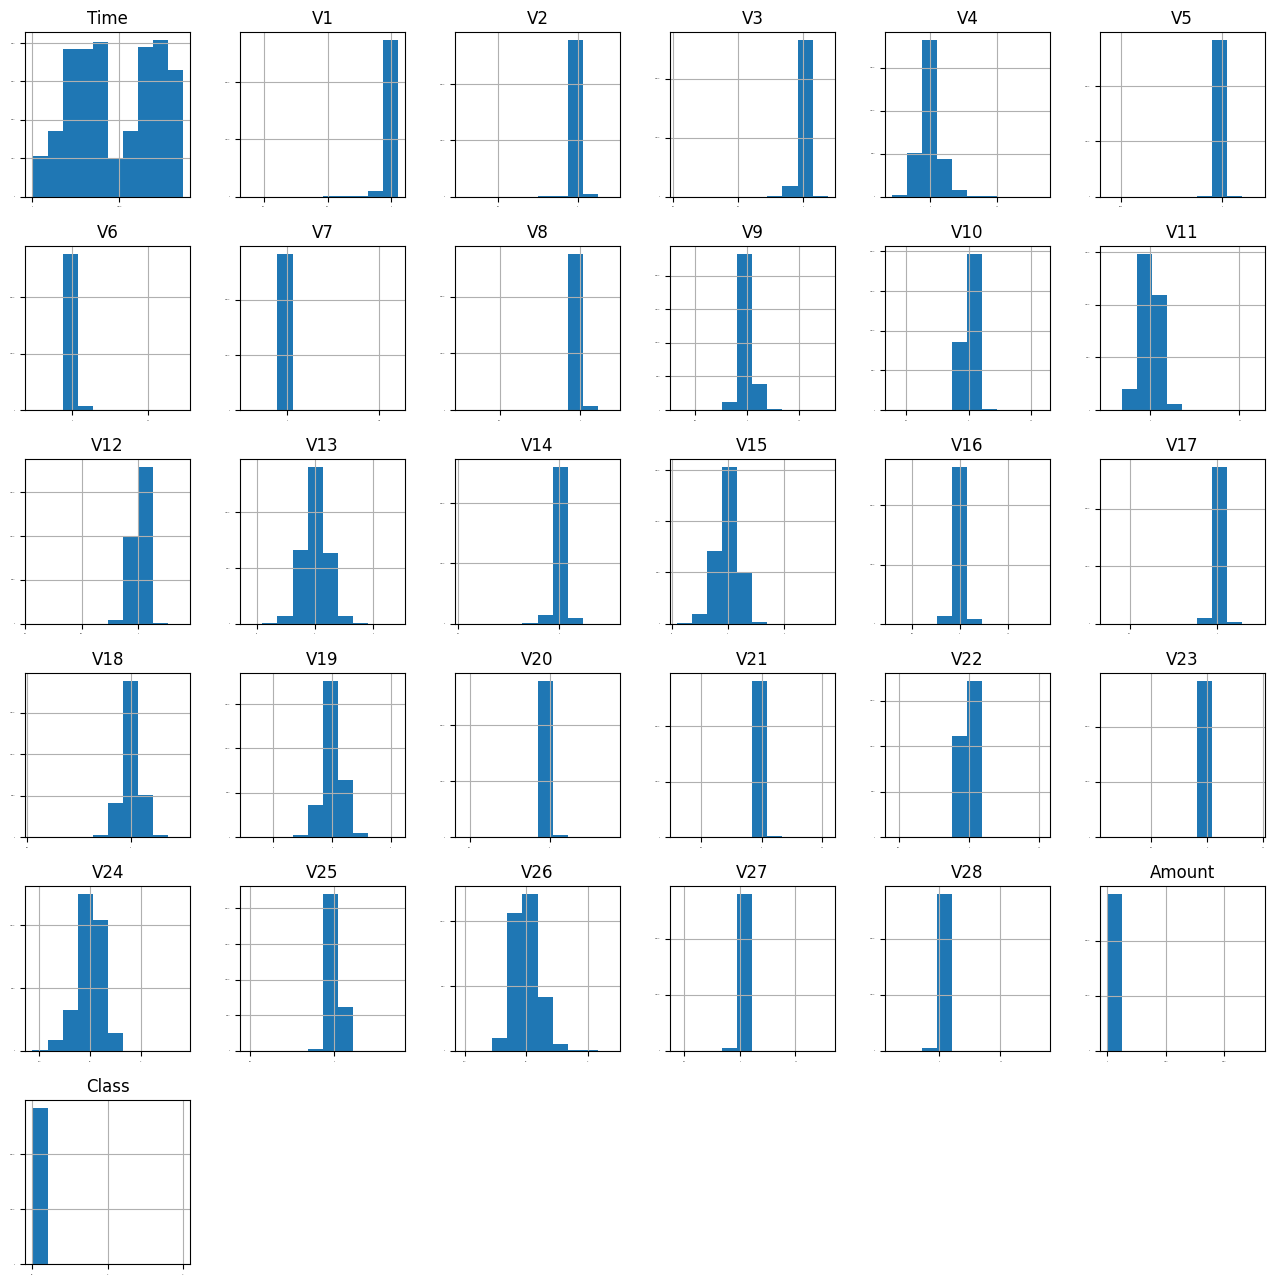

In [13]:
dataset.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1, figsize=(16,16))
pyplot.show()

We see skewness, but given the fact that we don't know what the variables are we can't do much

## Separate the original dataset

In [14]:
seed = 32

Y = dataset["Class"]
X = dataset.loc[:, dataset.columns != "Class"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=seed, stratify=Y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=seed, stratify=y_train_val
)

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)
print("\nClass ratios:")
print("train:\n", y_train.value_counts(normalize=True))
print("val:\n", y_val.value_counts(normalize=True))
print("test:\n", y_test.value_counts(normalize=True))

Shapes:
X_train: (170883, 30) y_train: (170883,)
X_val:   (56962, 30) y_val:   (56962,)
X_test:  (56962, 30) y_test:  (56962,)

Class ratios:
train:
 Class
0    0.998274
1    0.001726
Name: proportion, dtype: float64
val:
 Class
0    0.998262
1    0.001738
Name: proportion, dtype: float64
test:
 Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


## Evaluation protocol

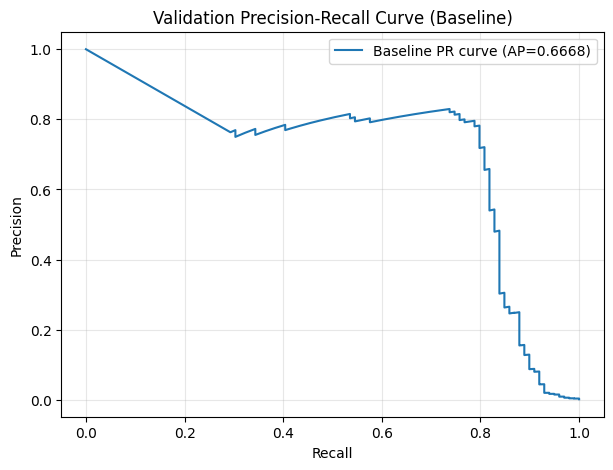

Validation PR-AUC: 0.6668
Validation F1 (threshold=0.5): 0.1290

Validation report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9999    0.9785    0.9891     56863
           1     0.0694    0.9192    0.1290        99

    accuracy                         0.9784     56962
   macro avg     0.5346    0.9489    0.5590     56962
weighted avg     0.9982    0.9784    0.9876     56962



In [ ]:
# baseline model + PR-AUC/F1 evaluation on validation set
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, classification_report
baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed))
])
baseline_pipe.fit(X_train, y_train)

# Probabilities for PR-AUC
val_proba = baseline_pipe.predict_proba(X_val)[:, 1] # get the probabilities of the positive class for each of the X_val

precision, recall, _ = precision_recall_curve(y_val, val_proba) # calculate the precision and recall for each of the probabilities to create the PR curve

val_pr_auc = average_precision_score(y_val, val_proba) # calculate the averageprecision score by comparing the predicted probabilities against the actual values

# Default threshold 0.5 for initial F1
val_pred_default = (val_proba >= 0.5).astype(int) # for all the cells with the probabilities over 0.5 will result in Boolean True, where the Boolean will be typecast to integer. True => 1, False => 0

val_f1_default = f1_score(y_val, val_pred_default) # calculate the F1 score by comparing the predicted values (val_pred_default) against the actual values (y_val)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Baseline PR curve (AP={val_pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curve (Baseline)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("============================")
print(f"Validation PR-AUC: {val_pr_auc:.4f}")
print(f"\nValidation F1 (threshold=0.5): {val_f1_default:.4f}")
print("\nValidation report (threshold=0.5):")
print("============================")
print(classification_report(y_val, val_pred_default, digits=4))

In [15]:
# choose threshold on validation to maximize F1

thresholds = np.arange(0.01, 1.00, 0.01)
f1_scores = [f1_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx])
best_f1 = float(f1_scores[best_idx])
print(f"Best validation threshold by F1: {best_threshold:.2f}")
print(f"Best validation F1: {best_f1:.4f}")

Best validation threshold by F1: 0.99
Best validation F1: 0.6983


In [16]:
# final evaluation on test set (using threshold chosen on validation only)
from sklearn.metrics import average_precision_score, f1_score, recall_score

test_proba = baseline_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

test_pr_auc = average_precision_score(y_test, test_proba)
test_f1 = f1_score(y_test, test_pred)
test_recall = recall_score(y_test, test_pred)

print(f"Test PR-AUC: {test_pr_auc:.4f}")
print(f"Test F1:     {test_f1:.4f}")
print(f"Test Recall: {test_recall:.4f}")

Test PR-AUC: 0.7562
Test F1:     0.7225
Test Recall: 0.8367


## Feature Selection

<Axes: >

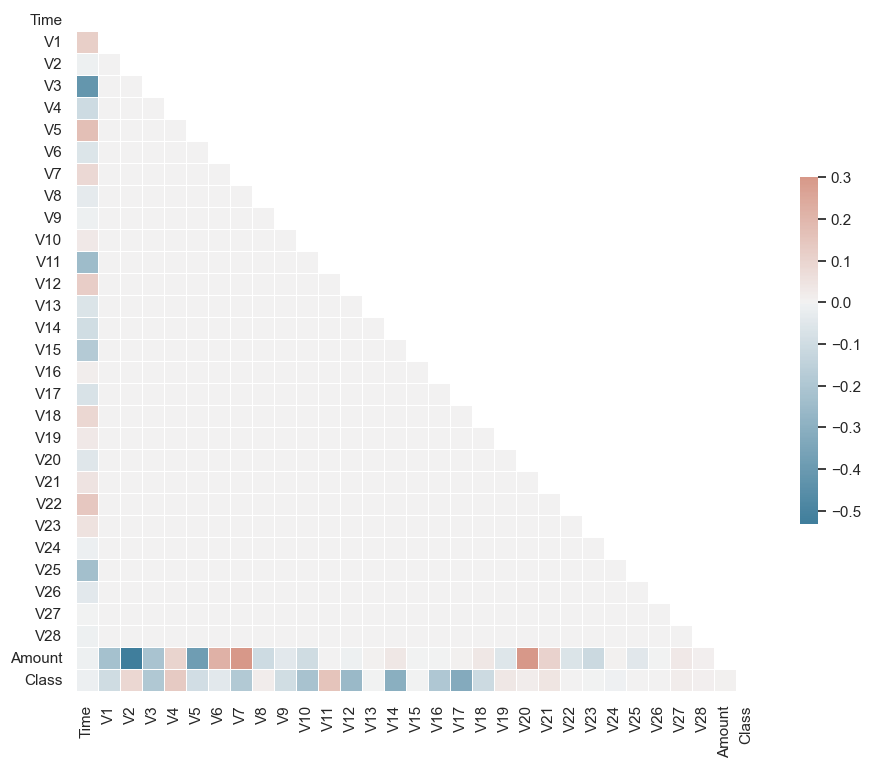

In [17]:
sns.set_theme(style="white")
corr = dataset.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [18]:
# Feature selection (train-only) using L1 logistic
from sklearn.feature_selection import SelectFromModel

selector_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectFromModel(
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=0.1,
            class_weight="balanced",
            random_state=seed,
            max_iter=2000
        ),
        threshold="median"   # keep roughly top half of non-zero/strong features
    ))
])

# Fit selector on TRAIN ONLY
selector_pipe.fit(X_train, y_train)

# Transform all splits with the train-fitted selector
X_train_sel = selector_pipe.transform(X_train)
X_val_sel   = selector_pipe.transform(X_val)
X_test_sel  = selector_pipe.transform(X_test)

# Recover selected feature names for interpretation
support_mask = selector_pipe.named_steps["selector"].get_support()
selected_features = X_train.columns[support_mask].tolist()

print("Original feature count:", X_train.shape[1])
print("Selected feature count:", len(selected_features))
print("First selected features:", selected_features[:20])

c:\Users\minim\MLcoursework\Classification Example\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\minim\MLcoursework\Classification Example\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Original feature count: 30
Selected feature count: 15
First selected features: ['Time', 'V1', 'V2', 'V4', 'V5', 'V6', 'V8', 'V10', 'V12', 'V13', 'V14', 'V16', 'V17', 'V20', 'Amount']


In [19]:
# Train model on selected features

model_sel = LogisticRegression(
    class_weight="balanced",
    random_state=seed,
    max_iter=2000
)
model_sel.fit(X_train_sel, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",32
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [20]:
# Validation metrics + threshold tuning (F1)

val_proba_sel = model_sel.predict_proba(X_val_sel)[:, 1]
val_pr_auc_sel = average_precision_score(y_val, val_proba_sel)

thresholds = np.arange(0.01, 1.00, 0.01)
f1_scores = [f1_score(y_val, (val_proba_sel >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(f1_scores))
best_threshold_sel = float(thresholds[best_idx])
best_f1_sel = float(f1_scores[best_idx])

print(f"Validation PR-AUC (selected): {val_pr_auc_sel:.4f}")
print(f"Best validation threshold: {best_threshold_sel:.2f}")
print(f"Best validation F1 (selected): {best_f1_sel:.4f}")

Validation PR-AUC (selected): 0.6628
Best validation threshold: 0.99
Best validation F1 (selected): 0.6953


In [21]:
# Final test evaluation (using threshold chosen on validation only)
from sklearn.metrics import precision_score

test_proba_sel = model_sel.predict_proba(X_test_sel)[:, 1]
test_pred_sel = (test_proba_sel >= best_threshold_sel).astype(int)

test_pr_auc_sel = average_precision_score(y_test, test_proba_sel)
test_f1_sel = f1_score(y_test, test_pred_sel)
test_recall_sel = recall_score(y_test, test_pred_sel)
test_precision_sel = precision_score(y_test, test_pred_sel)

print(f"Test PR-AUC (selected): {test_pr_auc_sel:.4f}")
print(f"Test F1 (selected):     {test_f1_sel:.4f}")
print(f"Test Recall (selected): {test_recall_sel:.4f}")
print(f"Test Precision(selected): {test_precision_sel:.4f}")

Test PR-AUC (selected): 0.7523
Test F1 (selected):     0.7354
Test Recall (selected): 0.8367
Test Precision(selected): 0.6560


In [22]:
# How sensitive is F1 near your chosen threshold?
for t in [0.95, 0.97, 0.99]:
    pred = (val_proba_sel >= t).astype(int)
    print("threshold: ", t, " | F1: " , f1_score(y_val, pred))

threshold:  0.95  | F1:  0.5665529010238908
threshold:  0.97  | F1:  0.6283524904214559
threshold:  0.99  | F1:  0.6952789699570815


## Retrain with different models

In [48]:
for i in [X_train, X_validation, Y_train, Y_validation]:
    print(i.shape)

(227845, 30)
(56962, 30)
(227845,)
(56962,)


In [50]:
num_folds = 10
models = []
models.append(('LR', LogisticRegression(random_state=seed, max_iter=5000)))
models.append(('CART', DecisionTreeClassifier(random_state=seed, max_depth=10, min_samples_split=20)))

Remember, the dataset is huge, so we should only use some simpler models. Here we use Logistic Regression and Classification and Regression Trees

In [53]:
from sklearn.preprocessing import StandardScaler

# initialize the scaler
scaler = StandardScaler()

# scale the features (X)
# important: scale X_train before passing it to cross_val_score
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

array([[ 1.20764306, -0.16270216,  0.99081019, ...,  0.3734089 ,
         0.79246085, -0.26972767],
       [-1.9442226 ,  0.59509705,  0.13958839, ..., -0.02937527,
         0.09352522, -0.29617486],
       [ 1.23522341,  0.73062371, -0.83542352, ..., -0.23106041,
        -0.06724883,  0.8576378 ],
       ...,
       [-0.81963906, -1.70549835, -0.85311055, ...,  1.07398306,
         2.17450254,  0.43888409],
       [-0.32315063,  0.74024178, -0.2734081 , ...,  0.02695066,
         0.04696881, -0.28827607],
       [-1.59908925, -0.3567994 ,  0.26021336, ..., -0.15653064,
        -0.46684   , -0.30065477]], shape=(227845, 30))

In [54]:
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(
        model, 
        X_train_scaled, 
        Y_train, 
        cv=kfold, 
        scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.999184 (0.000208)
CART: 0.999386 (0.000213)


In [ ]:
#from sklearn.model_selection import StratifiedKFold
#from sklearn.pipeline import make_pipeline
#results = []
#names = []
#for name, model in models:
    # build per-fold pipeline (prevents leakage & helps convergence)
#    pipeline = make_pipeline(StandardScaler(), model)

    # better for imbalanced classes than plain KFold
#    cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)
    
#    cv_results = cross_val_score(
#        pipeline, 
#        X_train,            # raw X is fine now because scaling is inside pipeline
#        Y_train, 
#        cv=cv, 
#        scoring=scoring,
#        n_jobs=-1)          # use all CPU cores
    
#    results.append(cv_results)
#    names.append(name)
#    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
#    print(msg)


LR: 0.999188 (0.000123)
CART: 0.999394 (0.000149)


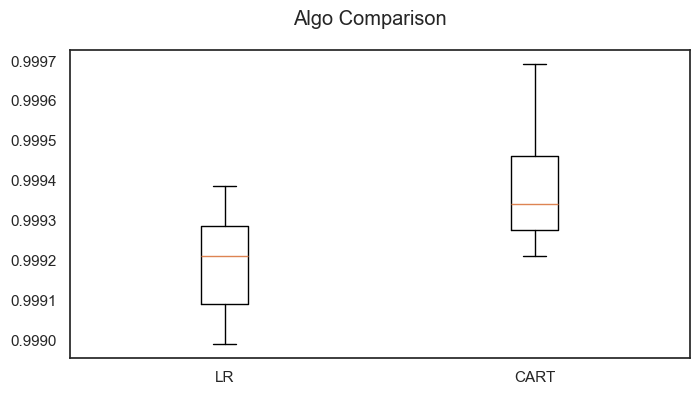

In [29]:
fig = pyplot.figure()
fig.suptitle('Algo Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
fig.set_size_inches(8,4)
pyplot.show()

We see the accuracy is quite high for both the cases with the algorithms with cross validation and 10 folds. Lets see how the performance is on unseen data with CART first and then Logistic Regression.

In [30]:
model = DecisionTreeClassifier(random_state=seed)
model.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",32
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [31]:
predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print('--------------------------------------------------------')
print(confusion_matrix(Y_validation, predictions))
print('--------------------------------------------------------')
print(classification_report(Y_validation, predictions))

0.9989642217618764
--------------------------------------------------------
[[56822    28]
 [   31    81]]
--------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56850
           1       0.74      0.72      0.73       112

    accuracy                           1.00     56962
   macro avg       0.87      0.86      0.87     56962
weighted avg       1.00      1.00      1.00     56962



We see that the model has a high accuracy on the validation/test set. But is this the most important measure? Lets look at the confusion matrix.

<Axes: xlabel='Predicted', ylabel='Actual'>

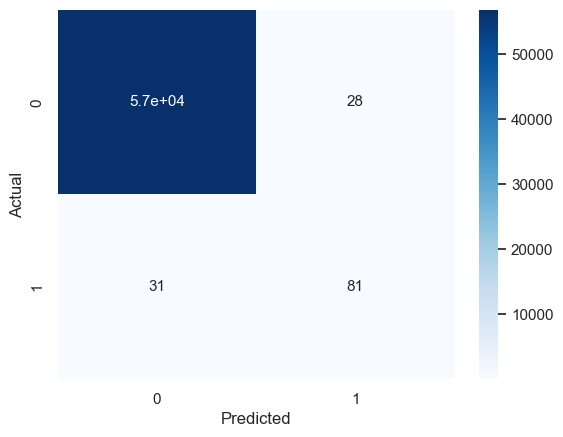

In [32]:
df_cm = pd.DataFrame(
    confusion_matrix(Y_validation, predictions), 
    columns=np.unique(Y_validation), 
    index = np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 11})

We see that although its good at predicting frauds, it sill misses 22 cases. Lets see the performance with Logistic Regression.

0.9991222218320986
--------------------------------------------------------
[[56843     7]
 [   43    69]]
--------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56850
           1       0.91      0.62      0.73       112

    accuracy                           1.00     56962
   macro avg       0.95      0.81      0.87     56962
weighted avg       1.00      1.00      1.00     56962



<Axes: xlabel='Predicted', ylabel='Actual'>

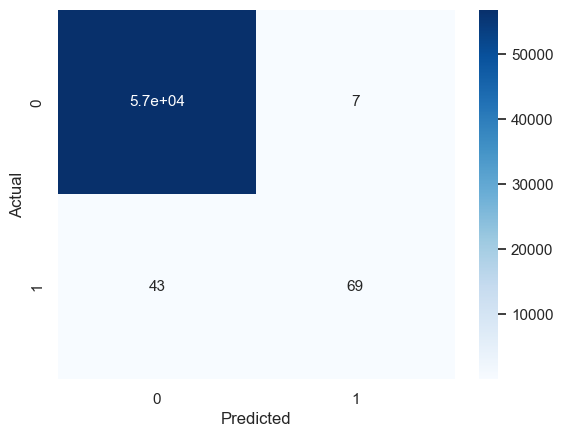

In [22]:
model = LogisticRegression(random_state=seed, max_iter=5000)
model.fit(X_train, Y_train)
predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print('--------------------------------------------------------')
print(confusion_matrix(Y_validation, predictions))
print('--------------------------------------------------------')
print(classification_report(Y_validation, predictions))
df_cm = pd.DataFrame(confusion_matrix(Y_validation, predictions), columns=np.unique(Y_validation), index = np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 11})

The Logistic Regression model is not too much worse than the CART model. It has 38 false negatives. Lets try and improve our models with undersampling.

## Undersampling

In [33]:
Y_train.value_counts()

Class
0    227465
1       380
Name: count, dtype: int64

We see that our validation/test set contains 112 out of the 492 fraud instances. We have 380 fraud instances in the training set. Lets undersample with these. Here we look to take randomly 380 non fraud cases to match with the 380 fraud case and train a model with this smaller set.

In [34]:
df = pd.concat([X_train, Y_train], axis=1)
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0].sample(frac=1, random_state=seed)[:380]
df_new = pd.concat([fraud_df, non_fraud_df])
# Shuffle the dataset
df_new = df_new.sample(frac=1, random_state=seed).reset_index(drop=True)
Y_train_new = df_new["Class"]
X_train_new = df_new.loc[:, dataset.columns != 'Class']

In [35]:
for i in [X_train_new, Y_train_new]:
    print(i.shape)

(760, 30)
(760,)


Distribution of the Classes in the subsample dataset
Class
1    0.5
0    0.5
Name: count, dtype: float64


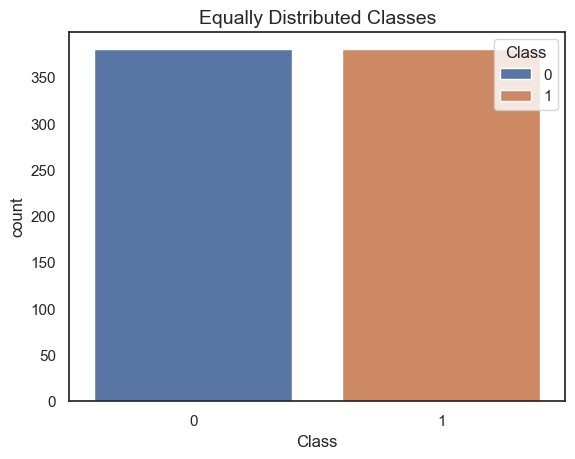

In [36]:
print('Distribution of the Classes in the subsample dataset')
print(df_new['Class'].value_counts()/len(df_new))
sns.countplot(x='Class', data=df_new, hue='Class')
pyplot.title('Equally Distributed Classes', fontsize=14)
pyplot.show()

We now have as many fraudulent and non-fraudulent cases, 405 instances of each.

## Try models with undersampled data

In [37]:
scoring='accuracy'

In [38]:
models = []
models.append(('LR', LogisticRegression(random_state=seed, max_iter=5000)))
models.append(('CART', DecisionTreeClassifier(random_state=seed, max_depth=10, min_samples_split=20)))

In [39]:
from sklearn.preprocessing import StandardScaler

# initialize the scaler
scaler = StandardScaler()

# scale the features (X)
# important: scale X_train_new before passing it to cross_val_score
X_train_new_scaled = scaler.fit_transform(X_train_new)
X_train_new_scaled

array([[-0.99615646, -1.98026664,  1.37022758, ..., -1.33552414,
        -1.01570254, -0.43270782],
       [-1.6225535 ,  0.60564254,  0.62702199, ...,  0.53255889,
         0.13844335, -0.43175655],
       [-1.44786825,  0.40963542, -0.44624079, ..., -0.28960213,
        -0.35678421, -0.41590198],
       ...,
       [-0.24550595,  0.63458894, -0.19980873, ...,  0.03823148,
         0.07449909, -0.43175655],
       [ 1.1783847 ,  0.76351472, -0.57296702, ..., -0.08817978,
        -0.15141311, -0.13281863],
       [ 1.32904678,  0.76173593, -0.88516147, ..., -0.01341948,
        -0.14253355,  0.04705146]], shape=(760, 30))

In [40]:
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train_new_scaled, Y_train_new, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.942105 (0.023684)
CART: 0.901316 (0.033417)


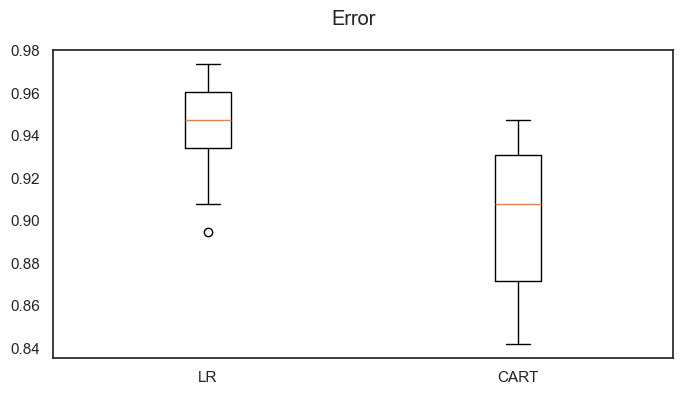

In [41]:
fig = pyplot.figure()
fig.suptitle('Error')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
fig.set_size_inches(8,4)
pyplot.show()

The Logistic Regression model appears to be more accurate than the CART model with this dataset. Lets run both models now on the full validation/test set.

In [42]:
model = DecisionTreeClassifier(random_state=seed)
model.fit(X_train_new, Y_train_new)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",32
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [43]:
predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.8932095080931147
[[50783  6067]
 [   16    96]]
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     56850
           1       0.02      0.86      0.03       112

    accuracy                           0.89     56962
   macro avg       0.51      0.88      0.49     56962
weighted avg       1.00      0.89      0.94     56962



<Axes: xlabel='Predicted', ylabel='Actual'>

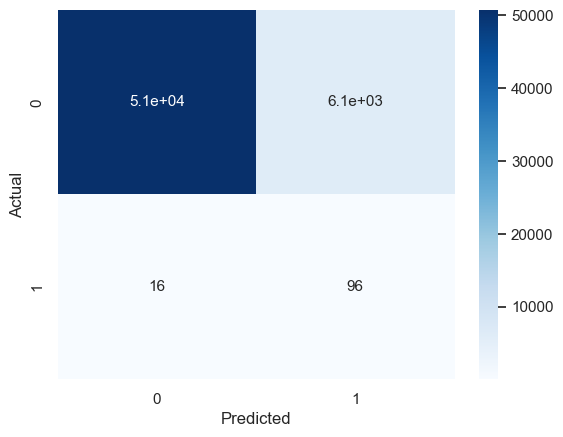

In [44]:
df_cm = pd.DataFrame(confusion_matrix(Y_validation, predictions), columns=np.unique(Y_validation), index = np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 11})

0.9667848741266107
[[54970  1880]
 [   12   100]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56850
           1       0.05      0.89      0.10       112

    accuracy                           0.97     56962
   macro avg       0.53      0.93      0.54     56962
weighted avg       1.00      0.97      0.98     56962



c:\Users\minim\MLcoursework\Classification Example\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Axes: xlabel='Predicted', ylabel='Actual'>

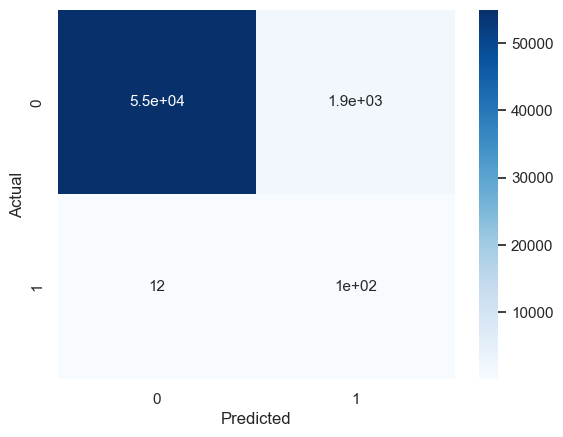

In [45]:
model = LogisticRegression(random_state=seed, max_iter=5000)
model.fit(X_train_new, Y_train_new)
predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))
df_cm = pd.DataFrame(confusion_matrix(Y_validation, predictions), columns=np.unique(Y_validation), index = np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 11})

We see that the number of false negatives decreases in both cases with the models. The Logistic Regression model improves much more than the CART model. Note how as the number of false negatives decreases, we see a large increase in the number of false positives. To improve the model, we could take further measures to reduce false negatives whilst also trying to control the increase in false positives.

There are a number of further steps we could take:
- Try different methods to deal with unbalanced data
- Regularise our models
- Try more complex models
- Feature engineering

## References
Adapted from *Machine Learning & Data Science Blueprints for Finance*; Tatsat et al.